# Autonomous Trajectory Synthesis using the MERGE Framework

This notebook implements the offline trajectory generation pipeline using **MERGE** (*Multi-Expert Regimes Gaussian Ensemble*). It processes multi-expert hardware demonstration rosbags, maps them into track-aligned spatial coordinates (Frenet frame), and clusters regions of high/low behavioral disagreement using Gaussian Mixture Models (GMM). 

The output is a smooth, continuous, and dynamically feasible reference trajectory optimized via Dynamic Programming and probabilistic blending, specifically formatted for real-time tracking using an adaptive Stanley controller on the physical F1TENTH racecar.

## 1. Imports and Environment Configuration

Load necessary scientific packages, ROS-compatible trajectory utility functions, dynamic models, and the core MERGE algorithmic handlers. Matplotlib visualization styles are configured to produce publication-ready vector plots.

In [19]:

# %matplotlib widget
import numpy as np
from os.path import join
from datetime import datetime
from functools import partial
from scipy.interpolate import splev, splrep

from f1tenth_gym_model.gym_car import Car
from f1tenth_gym_model.controllers import GeomtricControllersHub, simulate_controllers
from MERGE_utils.handler import SwitchingController, generate_opt_trajectory

from trajectory_utils.waypoint import WayPoint 
from trajectory_utils.plotter import plot_waypoints, plot_trajectory_data, set_publication_style
from trajectory_utils.data import traj_data_dict_get, save_traj_data, load_traj_data, print_details

set_publication_style()


In [27]:

# DUMMY PARAMS TO BE RE-WRITTEN

CAR_PARAMS = {
    'mu': 1.0489, 
    'C_Sf': 4.718, 
    'C_Sr': 5.4562, 
    'lf': 0.15875, 
    'lr': 0.17145, 
    'h': 0.074, 
    'm': 3.74,
    'I': 0.04712, 
    's_min': -0.4189, 
    's_max': 0.4189, 
    'sv_min': -3.2, 
    'sv_max': 3.2, 
    'v_switch': 7.319, 
    'a_max': 9.51, 
    'v_min':-5.0, 
    'v_max': 20.0, 
    'width': 0.31, 
    'length': 0.58,
    'g': 9.81,
    'dt': 1e-2,
    'X0': np.zeros(7),
}


## 3. Global Coordinates and Track Data Path

Set the session timestamp and identify the ground-truth racetrack map data (`Track_Data_Jan_21.txt`) converted from experimental rosbags.

In [21]:

FILEDATE = datetime.now().strftime("%Y-%m-%d_%H-%M")
RACE_TRACK_PATH = join("data_rosbags_converted", "MAP_DATA", "Track_Data_Jan_21.txt")


## 4. Track Centerline Discretization & Spline Fitting

Initialize the racetrack geometry using the `WayPoint` helper class. This generates a dense, smoothed centerline reference parameterized by normalized progress \(s \in [0, 1]\), and evaluates the track boundary envelopes for spatial safety evaluations.

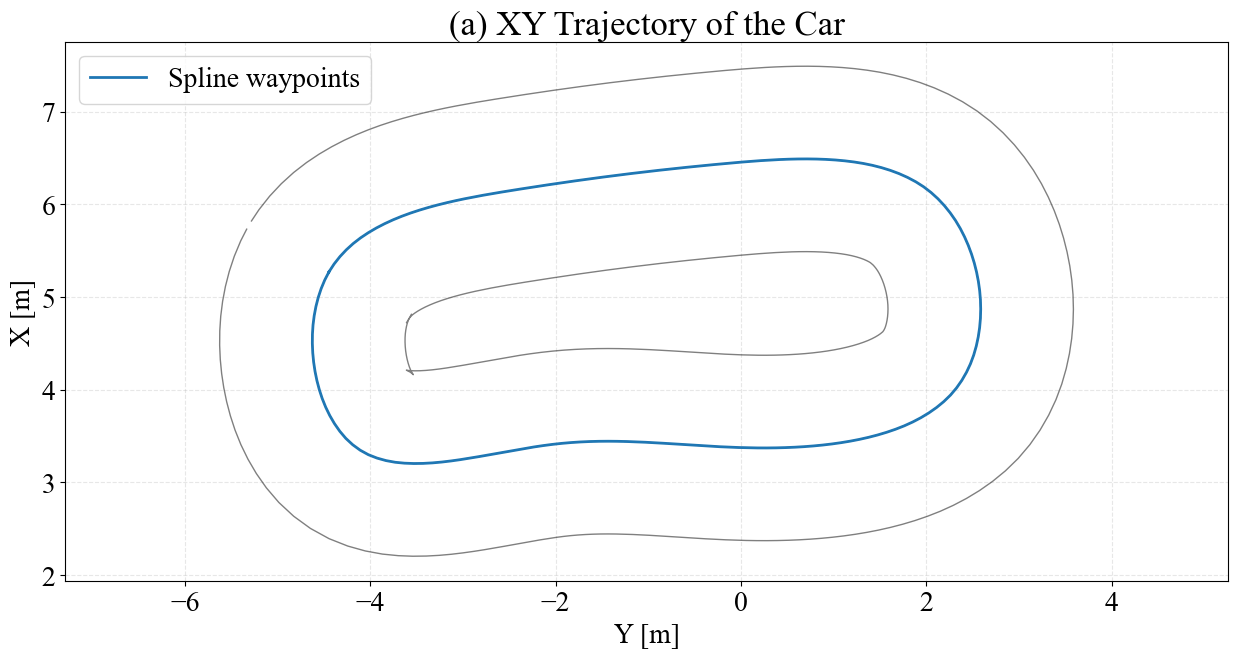

In [22]:

WP = WayPoint(
    path_to_waypts=RACE_TRACK_PATH, 
    waypoint_density=10.,
    waypoints_width=2.,
    smoothness_params=np.full(2, 0.),
)


## 5. Loading Hardware Demonstration Trajectories

Load recorded hardware driving demonstrations from the target `.pkl` bag file. The telemetry statistics—lap completion times, velocity profiles, and centerline lateral deviations—are inspected to assess the heterogeneity and sub-optimality of the demonstration manifold.

In [23]:

TRAJ_DATA_PATH = join("data_rosbags_converted", "DEMO_BAGS", "Track_Data_Jan_21.pkl")
TDList_Demo = load_traj_data(TRAJ_DATA_PATH)
print_details(TDList_Demo)


[INFO]: Trajectory Data loaded succesfully -> data_rosbags_converted\DEMO_BAGS\Track_Data_Jan_21.pkl
[INFO]: Lap Time Stats -> Min = 5.029 s
[INFO]: Lap Time Stats -> Mean = 7.9704 s
[INFO]: Lap Time Stats -> Max = 10.9723 s
[INFO]: Speed Stats -> Min = -0.0804 m/s
[INFO]: Speed Stats -> Mean = 1.8771 m/s
[INFO]: Speed Stats -> Max = 3.3198 m/s
[INFO]: Deviation Stats -> Min = 0.0001 m
[INFO]: Deviation Stats -> Mean = 0.2184 m
[INFO]: Deviation Stats -> Max = 0.9626 m


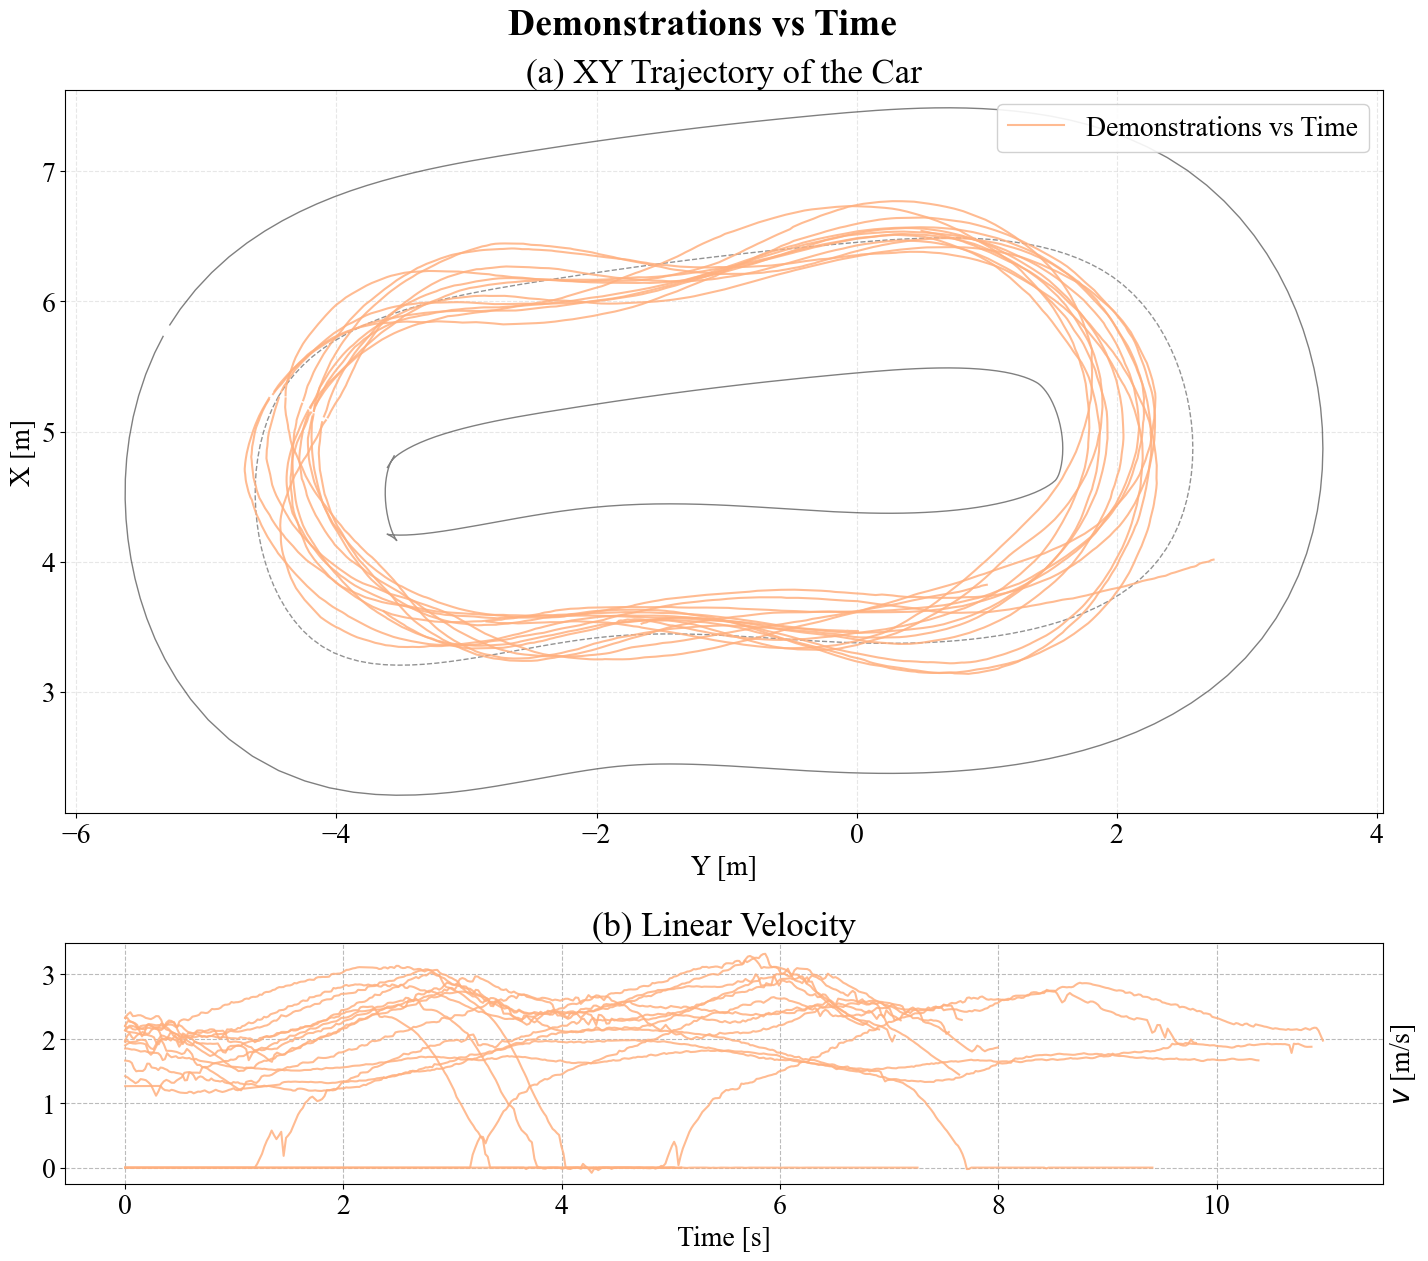

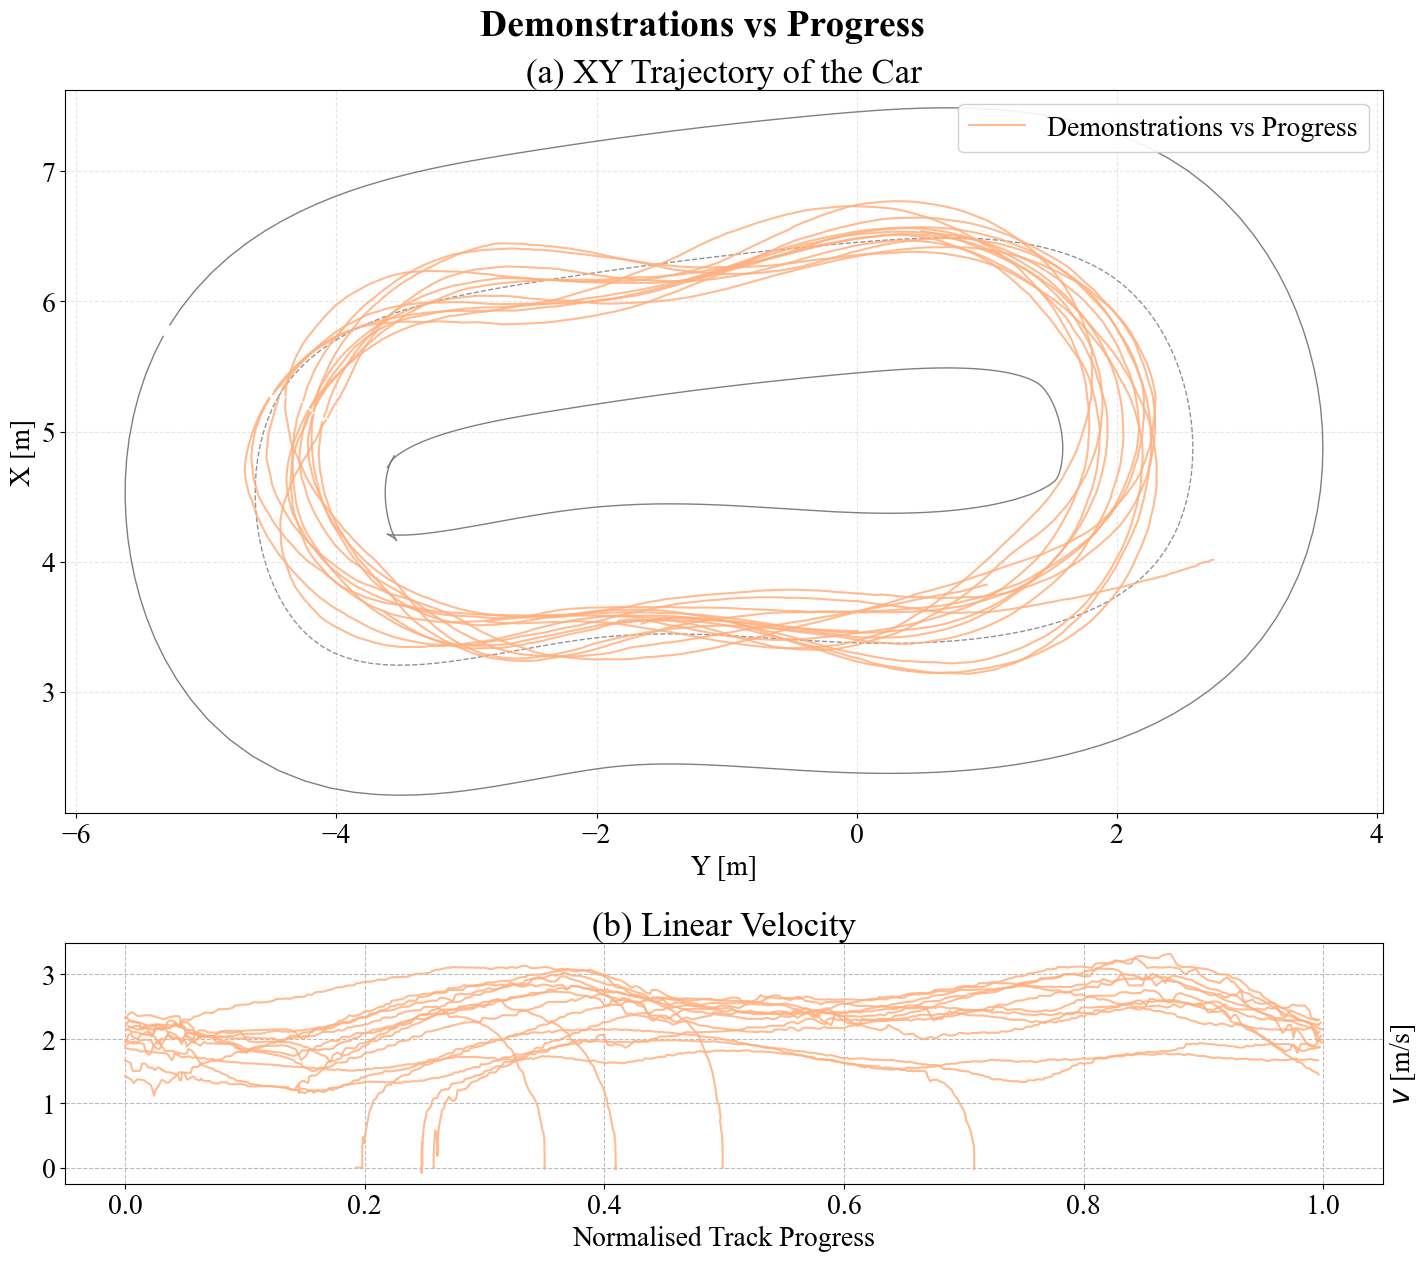

In [24]:

plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations vs Time",
    TD_learnt_name="", 
    filedate=FILEDATE
)
plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations vs Progress",
    TD_learnt_name="", 
    x_axis_time=False, 
)


## 6. Pre-Processing & Spatial Disagreement Visualization

Plot the raw Cartesian vehicle paths against track limits and centerline coordinates to visually inspect driving line divergence across expert demonstrations prior to GMM regime segmentation and Dynamic Programming sequence optimization.

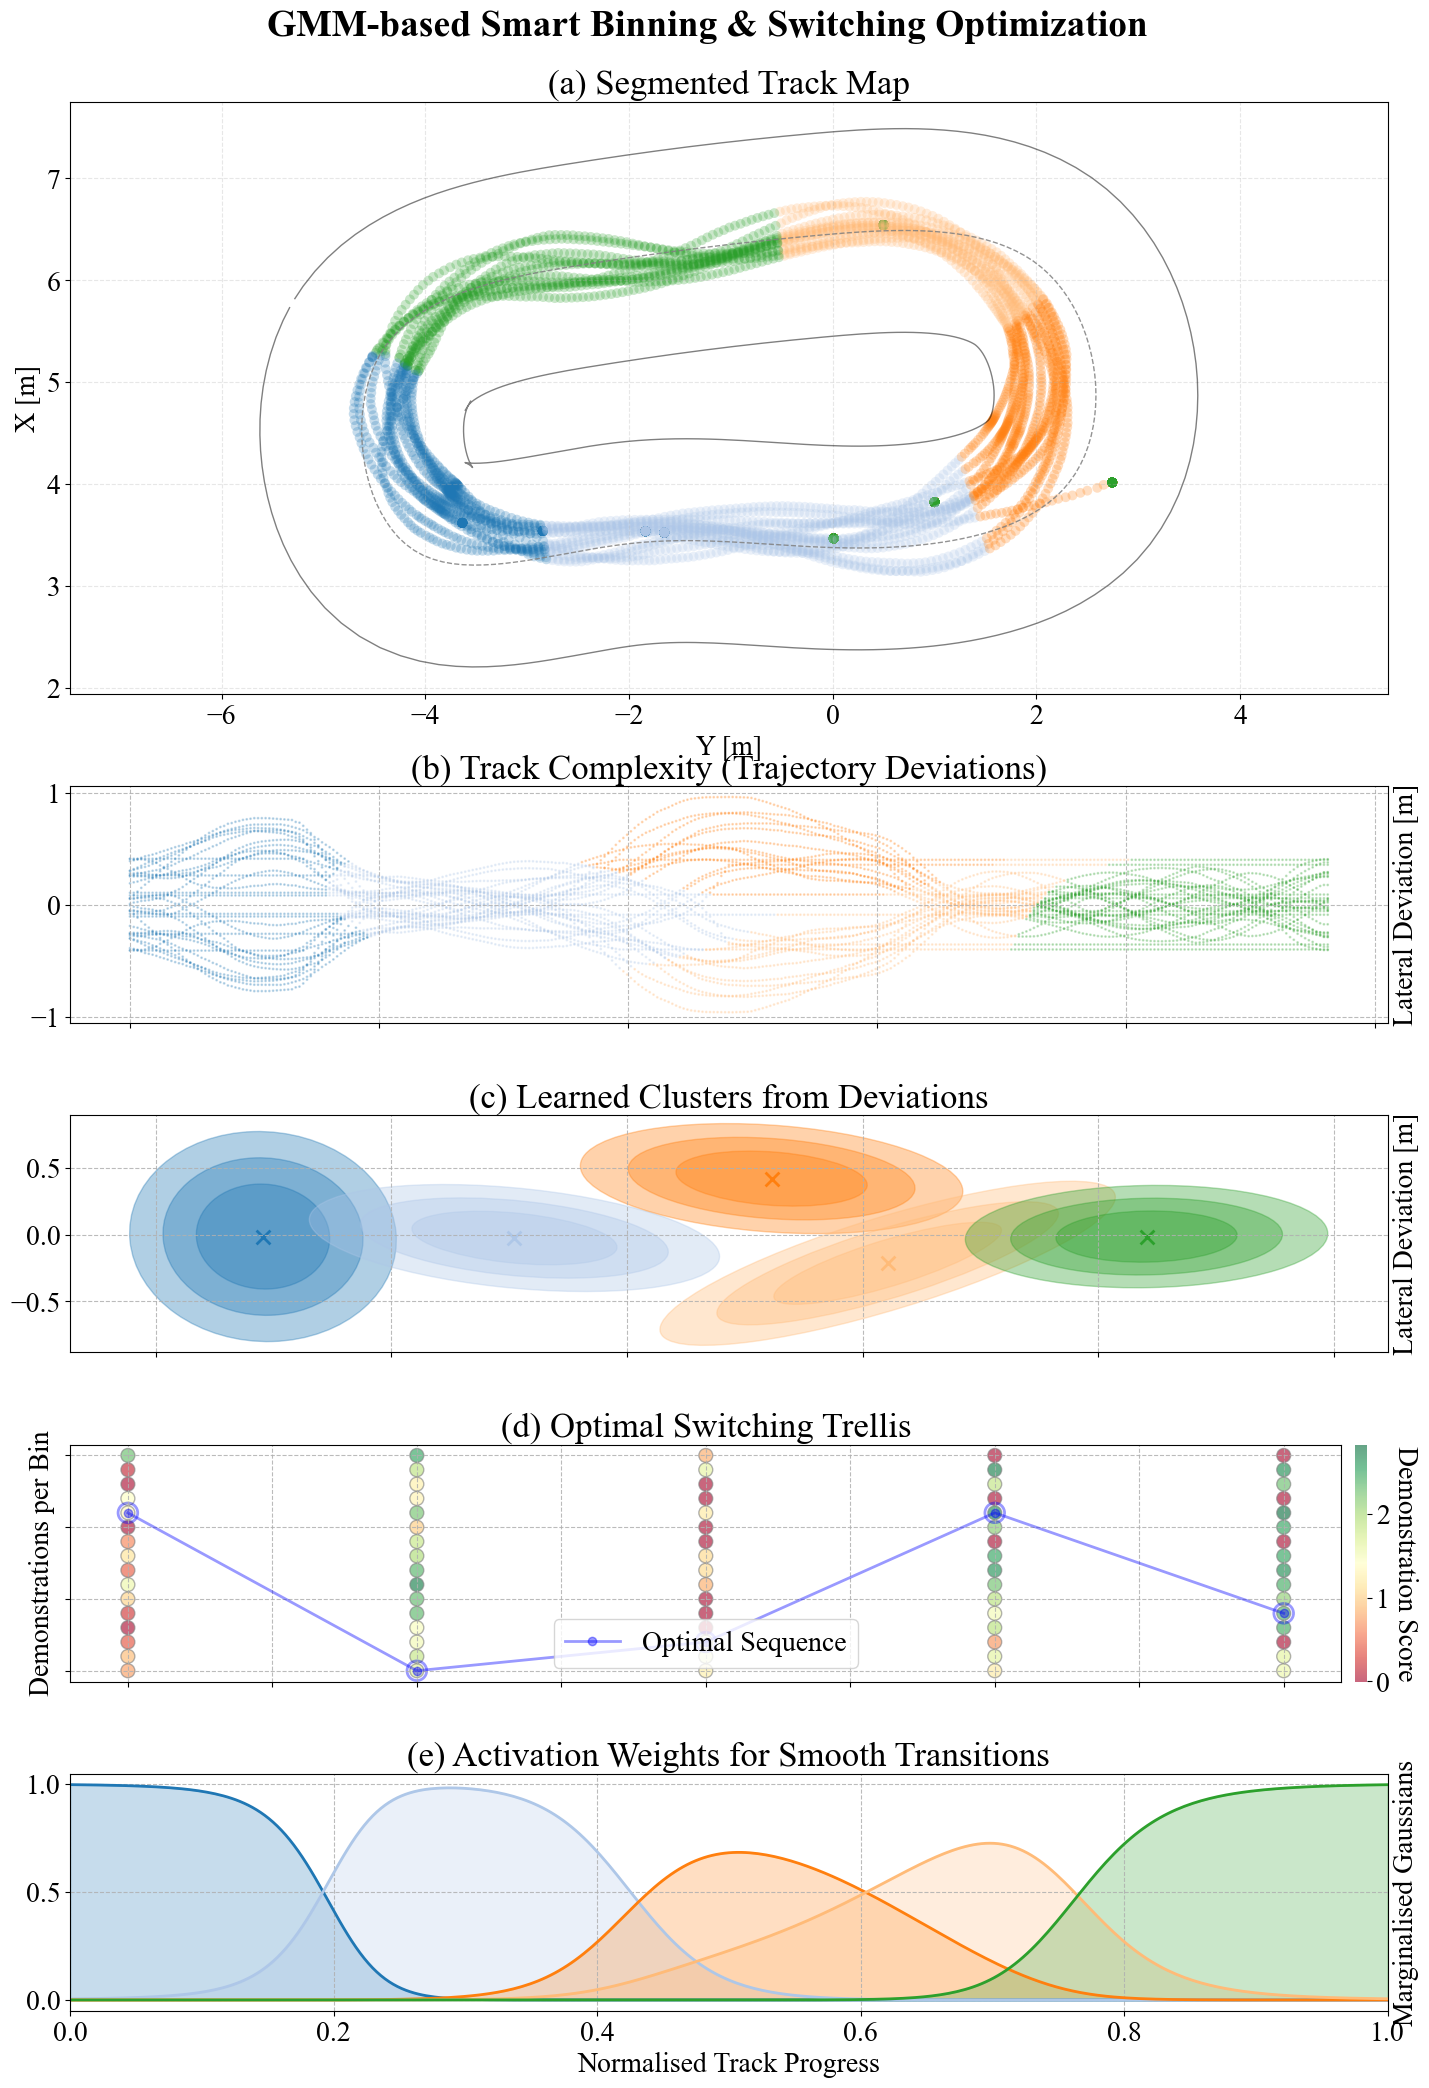

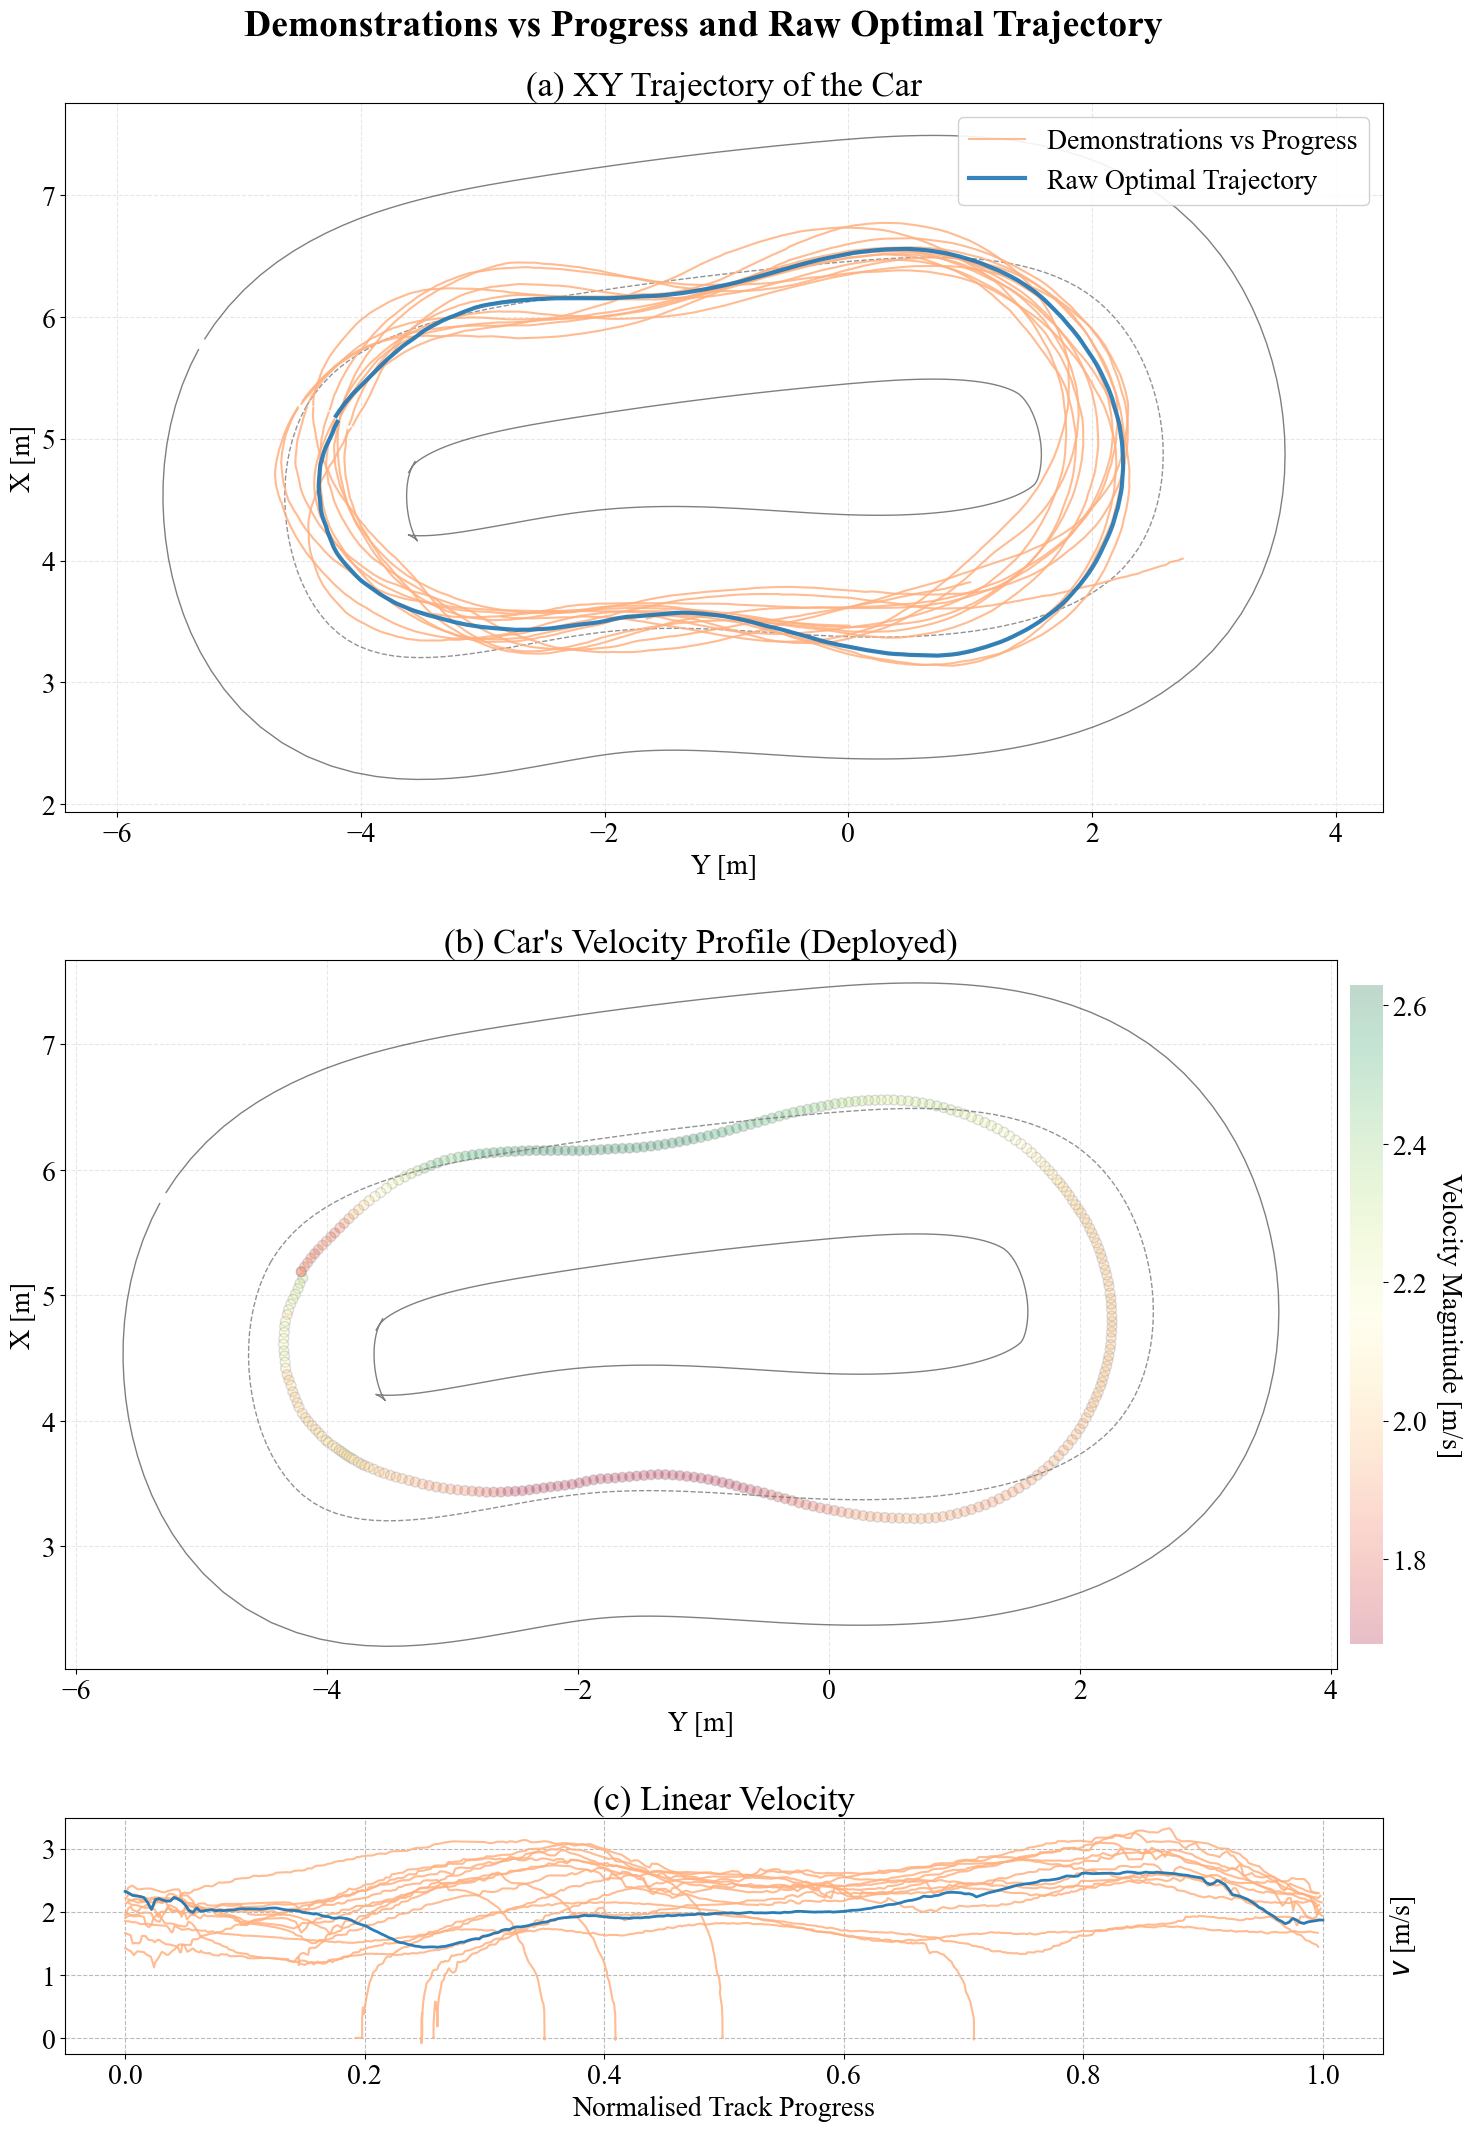

In [25]:

# TDList_Demo = sorted(TDList_Demo, key = lambda TD: TD["t_steps"][-1])

TDOpt = generate_opt_trajectory(
    TDList=TDList_Demo, 
    num_segs=5,
    acceleration_max=1.75,
    safety_width=0.6,
    safety_gain=3.5,
    switch_gain=3.5,
    downsample=1,
    filedate=FILEDATE,
    track_length=WP.cumulative_dists[-1],
    waypoints_plotter=partial(plot_waypoints, WP.waypoints, WP.waypoints_width),
)

plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_learnt=[TDOpt], 
    TDList_demo=TDList_Demo,
    TD_demo_name="Demonstrations vs Progress",
    TD_learnt_name="Raw Optimal Trajectory", 
    x_axis_time=False, 
    filedate=FILEDATE,
)


In [26]:

TRAJ_DATA_PATH = join("data_dummy", f"TDList_Learnt_{FILEDATE}.pkl")
save_traj_data(TDOpt, TRAJ_DATA_PATH)


[INFO]: Trajectory Data saved succesfully -> data_dummy\TDList_Learnt_2026-09-11_22-21.pkl
